In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import statsmodels.tsa.api as tsa
from pmdarima.model_selection import train_test_split
from pmdarima.arima.utils import ndiffs, nsdiffs
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
import pmdarima as pm

In [2]:
df = pd.read_csv('zillow_home_values-zipcode.csv')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 27442 entries, 0 to 27441
Columns: 284 entries, RegionID to 30112022
dtypes: float64(275), int64(3), str(6)
memory usage: 59.5 MB


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,31012000,...,28022022,31032022,30042022,31052022,30062022,31072022,31082022,30092022,31102022,30112022
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0,...,261945.0,267644.0,273946.0,280066.0,285121.0,288532.0,290458.0,291103.0,292081.0,292948.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0,...,453150.0,464727.0,478369.0,489712.0,497173.0,499429.0,497572.0,498113.0,500187.0,503109.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0,...,177319.0,179463.0,182812.0,186403.0,189836.0,192064.0,193760.0,195140.0,196787.0,198137.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0,...,570211.0,572145.0,573662.0,576469.0,578706.0,580834.0,581779.0,584566.0,588188.0,590722.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0,...,752025.0,757734.0,760336.0,766163.0,771443.0,776607.0,779281.0,782367.0,788211.0,793924.0


In [4]:
melted = pd.melt(df, id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName'], var_name='Date', value_name='Value')
melted.info()
melted.head()

<class 'pandas.DataFrame'>
RangeIndex: 7546550 entries, 0 to 7546549
Data columns (total 11 columns):
 #   Column      Dtype  
---  ------      -----  
 0   RegionID    int64  
 1   SizeRank    int64  
 2   RegionName  int64  
 3   RegionType  str    
 4   StateName   str    
 5   State       str    
 6   City        str    
 7   Metro       str    
 8   CountyName  str    
 9   Date        str    
 10  Value       float64
dtypes: float64(1), int64(3), str(7)
memory usage: 633.3 MB


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,31012000,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,31012000,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,31012000,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,31012000,275983.0


In [7]:
melted['Date'] = pd.to_datetime(melted['Date'], format='%d%m%Y').dt.strftime('%d/%m/%Y')
melted.info()


<class 'pandas.DataFrame'>
RangeIndex: 7546550 entries, 0 to 7546549
Data columns (total 11 columns):
 #   Column      Dtype  
---  ------      -----  
 0   RegionID    int64  
 1   SizeRank    int64  
 2   RegionName  int64  
 3   RegionType  str    
 4   StateName   str    
 5   State       str    
 6   City        str    
 7   Metro       str    
 8   CountyName  str    
 9   Date        str    
 10  Value       float64
dtypes: float64(1), int64(3), str(7)
memory usage: 633.3 MB


In [10]:
melted['Date'] = pd.to_datetime(melted['Date'])

C:\Users\Eng-Mohammed\AppData\Local\Temp\ipykernel_27740\3351856047.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  melted['Date'] = pd.to_datetime(melted['Date'])


In [11]:
melted.info()

<class 'pandas.DataFrame'>
RangeIndex: 7546550 entries, 0 to 7546549
Data columns (total 11 columns):
 #   Column      Dtype         
---  ------      -----         
 0   RegionID    int64         
 1   SizeRank    int64         
 2   RegionName  int64         
 3   RegionType  str           
 4   StateName   str           
 5   State       str           
 6   City        str           
 7   Metro       str           
 8   CountyName  str           
 9   Date        datetime64[us]
 10  Value       float64       
dtypes: datetime64[us](1), float64(1), int64(3), str(6)
memory usage: 633.3 MB


In [12]:
melted.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,2000-01-31,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,2000-01-31,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,275983.0


In [13]:
melted['Home Value'] = melted['Value'].astype(float)
melted.drop(columns=['Value'], inplace=True)

In [14]:
melted.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Date,Home Value
0,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,107261.0
1,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,2000-01-31,222569.0
2,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,2000-01-31,90009.0
3,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,188096.0
4,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,275983.0


In [15]:
ts = melted.set_index('Date').sort_index()
ts.info()
ts.head()

<class 'pandas.DataFrame'>
DatetimeIndex: 7546550 entries, 2000-01-31 to 2022-11-30
Data columns (total 10 columns):
 #   Column      Dtype  
---  ------      -----  
 0   RegionID    int64  
 1   SizeRank    int64  
 2   RegionName  int64  
 3   RegionType  str    
 4   StateName   str    
 5   State       str    
 6   City        str    
 7   Metro       str    
 8   CountyName  str    
 9   Home Value  float64
dtypes: float64(1), int64(3), str(6)
memory usage: 633.3 MB


,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,Home Value
Date,,,,,,,,,,
2000-01-31,91940,0,77449,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Harris County,107261.0
2000-01-31,91982,1,77494,zip,TX,TX,NaN,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,222569.0
2000-01-31,93144,2,79936,zip,TX,TX,El Paso,"El Paso, TX",El Paso County,90009.0
2000-01-31,62080,3,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,188096.0
2000-01-31,62093,4,11385,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,275983.0


In [18]:
tableau_ts = ts[ts['State'].isin(['CA', 'WA', 'OR', 'AZ', 'NV'])].loc['2010':'2020']
tableau_ts.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 386892 entries, 2010-01-31 to 2020-12-31
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   RegionID    386892 non-null  int64  
 1   SizeRank    386892 non-null  int64  
 2   RegionName  386892 non-null  int64  
 3   RegionType  386892 non-null  str    
 4   StateName   386892 non-null  str    
 5   State       386892 non-null  str    
 6   City        374748 non-null  str    
 7   Metro       352308 non-null  str    
 8   CountyName  386892 non-null  str    
 9   Home Value  361506 non-null  float64
dtypes: float64(1), int64(3), str(6)
memory usage: 32.5 MB


In [20]:
tableau_ts.to_csv('Data/tableau_ts.csv', index=True)

In [22]:
ts.isna().sum().sum()

np.int64(3863126)

In [23]:
ts.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 7546550 entries, 2000-01-31 to 2022-11-30
Data columns (total 10 columns):
 #   Column      Dtype  
---  ------      -----  
 0   RegionID    int64  
 1   SizeRank    int64  
 2   RegionName  int64  
 3   RegionType  str    
 4   StateName   str    
 5   State       str    
 6   City        str    
 7   Metro       str    
 8   CountyName  str    
 9   Home Value  float64
dtypes: float64(1), int64(3), str(6)
memory usage: 633.3 MB


In [40]:
ts_res = ts.groupby('State')['Home Value'].resample('YS').mean()

In [41]:
ts_res.head(100)

State  Date      
AK     2000-01-01    164336.314103
       2001-01-01    185267.269231
       2002-01-01    201922.198718
       2003-01-01    212610.250000
       2004-01-01    227255.865385
                         ...      
CA     2003-01-01    407454.088086
       2004-01-01    480770.919879
       2005-01-01    569840.343171
       2006-01-01    621185.124784
       2007-01-01    589620.212881
Name: Home Value, Length: 100, dtype: float64

Plot a line graph with each state as a seperate line

In [44]:
unstacked = ts_res.unstack(level=0)
unstacked.head()

State,AK,AL,AR,AZ,CA,CO,CT,DC,DE,FL,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,164336.314103,104295.604924,72952.144137,144617.693227,292716.325457,207476.563525,195698.655594,220958.130952,166396.779070,130957.702844,...,NaN,95163.383316,145197.406606,202329.980271,172983.563178,132778.352018,200610.510645,151642.598639,77079.060633,NaN
2001-01-01,185267.269231,110670.245682,76204.998347,153287.234613,328871.707555,231662.722888,212517.907986,246910.595238,183763.472868,142203.355831,...,NaN,99046.263427,145291.417625,209367.273649,190785.903024,142413.037778,207948.309911,158689.634015,80319.937766,NaN
2002-01-01,201922.198718,115140.543428,78397.039652,160552.324561,360125.969093,241377.004022,233627.347222,288059.273810,200096.027132,156663.259718,...,NaN,101538.269081,147934.953009,210883.724099,209062.034980,152442.887383,213750.963357,164055.254699,82932.004252,145227.930233
2003-01-01,212610.250000,117486.532998,80488.862765,169506.943512,407454.088086,245074.049341,261466.127474,335054.785714,225983.988372,174336.099970,...,NaN,103968.173596,150959.546947,210532.537768,229536.486226,162603.622098,221952.369155,173253.638003,85565.348117,149140.600000
2004-01-01,227255.865385,121967.654991,84942.106339,185472.360735,480770.919879,249699.560735,290373.271991,389526.599206,259660.222868,193337.296195,...,NaN,108150.388097,158107.519881,213899.158784,265547.771468,182552.355288,240977.896778,187850.972961,88547.562353,158929.525424


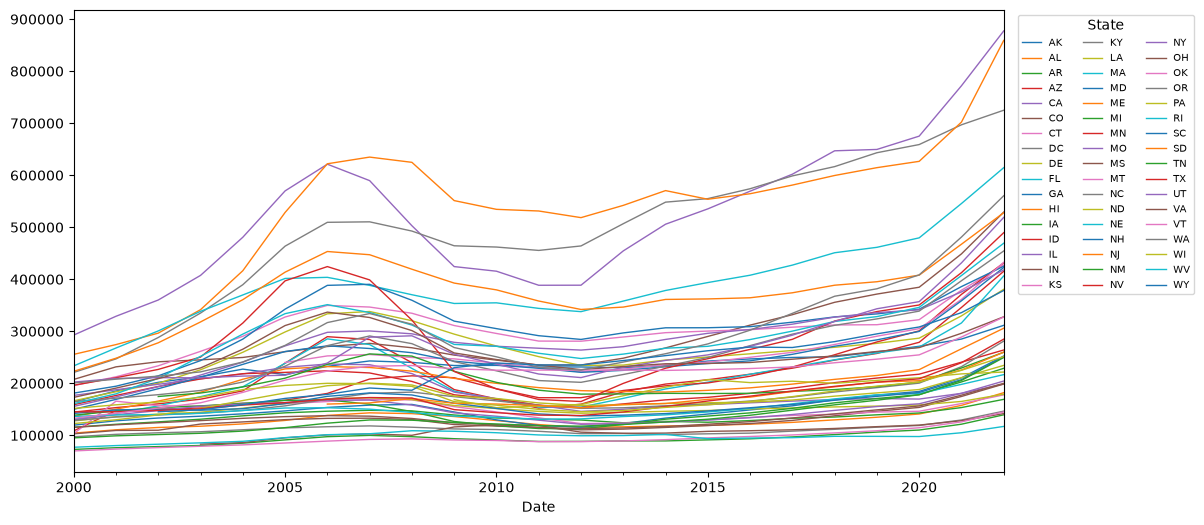

In [49]:
fig, ax = plt.subplots(figsize=(12, 6))
ax = unstacked.plot(ax=ax, linewidth=1)
ax.legend(title='State', loc='upper left', bbox_to_anchor=(1.01, 1),
          fontsize='x-small', ncol=3)

In [47]:
ts_res.isna().sum().sum()

np.int64(27)

In [48]:
ts_res.loc[ts_res.isna(), :]

State  Date      
MS     2000-01-01   NaN
       2001-01-01   NaN
       2002-01-01   NaN
MT     2000-01-01   NaN
       2001-01-01   NaN
       2002-01-01   NaN
       2003-01-01   NaN
       2004-01-01   NaN
ND     2000-01-01   NaN
       2001-01-01   NaN
       2002-01-01   NaN
       2003-01-01   NaN
       2004-01-01   NaN
       2005-01-01   NaN
       2006-01-01   NaN
       2007-01-01   NaN
       2008-01-01   NaN
NM     2000-01-01   NaN
       2001-01-01   NaN
SD     2000-01-01   NaN
       2001-01-01   NaN
       2002-01-01   NaN
       2003-01-01   NaN
       2004-01-01   NaN
       2005-01-01   NaN
WY     2000-01-01   NaN
       2001-01-01   NaN
Name: Home Value, dtype: float64

## Part2

Now we will start with creating the forecasting models.

First we will get the data for oregon state only and then resample it to monthly data.

In [55]:
ts_oregon_monthly = ts.loc[ts['State'] == "OR", "Home Value"].resample('ME').mean()

In [56]:
ts_oregon_monthly.info()

<class 'pandas.Series'>
DatetimeIndex: 275 entries, 2000-01-31 to 2022-11-30
Freq: ME
Series name: Home Value
Non-Null Count  Dtype  
--------------  -----  
275 non-null    float64
dtypes: float64(1)
memory usage: 4.3 KB


In [57]:
ts_oregon_monthly.head()

Date
2000-01-31    162508.613445
2000-02-29    162913.172269
2000-03-31    163011.125523
2000-04-30    163541.908333
2000-05-31    164176.420833
Freq: ME, Name: Home Value, dtype: float64

Now let's locate the home values from 2000 to 2018

In [58]:
ts_oregon_monthly = ts_oregon_monthly.loc['2000-01-31':'2018-12-31']

In [59]:
ts_oregon_monthly.head()

Date
2000-01-31    162508.613445
2000-02-29    162913.172269
2000-03-31    163011.125523
2000-04-30    163541.908333
2000-05-31    164176.420833
Freq: ME, Name: Home Value, dtype: float64

In [61]:
ts_oregon_monthly.tail()

Date
2018-08-31    313844.697059
2018-09-30    315055.305882
2018-10-31    316216.785294
2018-11-30    317505.623529
2018-12-31    319024.661765
Freq: ME, Name: Home Value, dtype: float64

Address null values.

In [63]:
ts_oregon_monthly.isna().sum()

np.int64(0)

No null values found so we can move forward.

Now we will put here the custom functions that we are going to use during our arima forecasting.

In [64]:
def plot_forecast(ts_train, ts_test, forecast_df, n_train_lags=None,
                  figsize=(10,4), title='Comparing Forecast vs. True Data'):
    ### PLot training data, and forecast (with upper/,lower ci)
    fig, ax = plt.subplots(figsize=figsize)

    # setting the number of train lags to plot if not specified
    if n_train_lags==None:
        n_train_lags = len(ts_train)

    # Plotting Training  and test data
    ts_train.iloc[-n_train_lags:].plot(ax=ax, label="train")
    ts_test.plot(label="test", ax=ax)

    # Plot forecast
    forecast_df['mean'].plot(ax=ax, color='green', label="forecast")

    # Add the shaded confidence interval
    ax.fill_between(forecast_df.index,
                    forecast_df['mean_ci_lower'],
                   forecast_df['mean_ci_upper'],
                   color='green', alpha=0.3,  lw=2)

    # set the title and add legend
    ax.set_title(title)
    ax.legend();

    return fig, ax

In [65]:
# Custom function for Ad Fuller Test
def get_adfuller_results(ts, alpha=.05, label='adfuller', **kwargs): #kwargs for adfuller()
    # Saving each output
    (test_stat, pval, nlags, nobs, crit_vals_d,
    icbest ) = tsa.adfuller(ts, **kwargs)
    # Converting output to a dictionary with the interpretation of p
    adfuller_results = {'Test Statistic': test_stat,
                        "# of Lags Used":nlags,
                       '# of Observations':nobs,
                        'p-value': round(pval,6),
                        'alpha': alpha,
                       'sig/stationary?': pval < alpha}
    return pd.DataFrame(adfuller_results, index =[label])

In [66]:
def regression_metrics_ts(ts_true, ts_pred, label="", verbose=True, output_dict=False,):
    # Get metrics
    mae = mean_absolute_error(ts_true, ts_pred)
    mse = mean_squared_error(ts_true, ts_pred)
    rmse = root_mean_squared_error(ts_true, ts_pred)
    r_squared = r2_score(ts_true, ts_pred)
    mae_perc = mean_absolute_percentage_error(ts_true, ts_pred) * 100

    if verbose == True:
        # Print Result with label
        header = "---" * 20
        print(header, f"Regression Metrics: {label}", header, sep="\n")
        print(f"- MAE = {mae:,.3f}")
        print(f"- MSE = {mse:,.3f}")
        print(f"- RMSE = {rmse:,.3f}")
        print(f"- R^2 = {r_squared:,.3f}")
        print(f"- MAPE = {mae_perc:,.2f}%")

    if output_dict == True:
        metrics = {
            "Label": label,
            "MAE": mae,
            "MSE": mse,
            "RMSE": rmse,
            "R^2": r_squared,
            "MAPE(%)": mae_perc,
        }
        return metrics

In [67]:
def get_sig_lags(ts, type='ACF',  nlags=None,alpha=0.5):


    if type == 'ACF':
        # Running the function used by plot_acf
        corr_values, conf_int = tsa.stattools.acf(ts, alpha=alpha, nlags=nlags)

    elif type=='PACF':
        corr_values, conf_int = tsa.stattools.pacf(ts, alpha=alpha, nlags=nlags)

    else:
        raise Exception("type must be either 'ACF' or 'PACF'")

    # Determine lags
    lags =range(len(corr_values))

    # Create a centered version of the acf_df
    corr_df = pd.DataFrame({type:corr_values,
                            'Lags':lags,
                            'lower ci': conf_int[:,0]-corr_values, # subtract acf from lower ci to center
                            'upper ci': conf_int[:,1]-corr_values, # subtact acf to upper ci to center
                                 })
    corr_df = corr_df.set_index("Lags")

    # Getting filter for sig lags
    filter_sig_lags = (corr_df[type] < corr_df['lower ci']) | (corr_df[type] > corr_df['upper ci'])

    # Get lag #'s
    sig_lags= corr_df.index[filter_sig_lags]
    sig_lags = sig_lags[sig_lags!=0]

    return sig_lags

In [68]:
def plot_acf_pacf(ts, nlags=40, figsize=(10, 5),
                  annotate_sig=False, alpha=.05,
                 acf_kws={}, pacf_kws={},
                  annotate_seas=False, m = None,
                 seas_color='black'):

    fig, axes = plt.subplots(nrows=2, figsize=figsize)


    # Sig lags line style
    sig_vline_kwargs = dict( ls=':', lw=1, zorder=0, color='red')

    # ACF
    tsa.graphics.plot_acf(ts, ax=axes[0], lags=nlags, **acf_kws)

    ## Annotating sig acf lags
    if annotate_sig == True:
        sig_acf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='ACF')
        for lag in sig_acf_lags:
            axes[0].axvline(lag,label='sig', **sig_vline_kwargs )

    # PACF
    tsa.graphics.plot_pacf(ts,ax=axes[1], lags=nlags, **pacf_kws)

    ## Annotating sig pacf lags
    if annotate_sig == True:
        ## ANNOTATING SIG LAGS
        sig_pacf_lags = get_sig_lags(ts,nlags=nlags,alpha=alpha, type='PACF')
        for lag in sig_pacf_lags:
            axes[1].axvline(lag, label='sig', **sig_vline_kwargs)




    ### ANNOTATE SEASONS
    if annotate_seas == True:
        # Ensure m was defined
        if m is None:
            raise Exception("Must define value of m if annotate_seas=True.")

        ## Calculate number of complete seasons to annotate
        n_seasons = nlags//m

        # Seasonal Lines style
        seas_vline_kwargs = dict( ls='--',lw=1, alpha=.7, color=seas_color, zorder=-1)

        ## for each season, add a line
        for i in range(1, n_seasons+1):
            axes[0].axvline(m*i, **seas_vline_kwargs, label="season")
            axes[1].axvline(m*i, **seas_vline_kwargs, label="season")

    fig.tight_layout()

    return fig

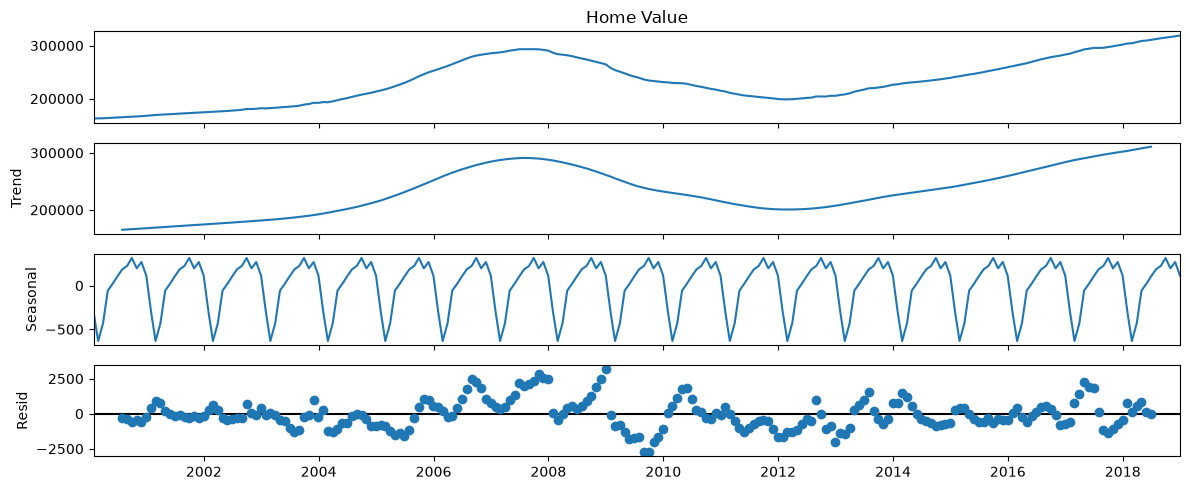

In [69]:
# Apply seasonal decomposition
decomp = tsa.seasonal_decompose(ts_oregon_monthly)
fig = decomp.plot()
fig.set_size_inches(12,5)
fig.tight_layout()

In [71]:
# How big is the seasonal component
seasonal_delta = decomp.seasonal.max() - decomp.seasonal.min()

# How big is the seasonal component relative to the time series?
print(f"The seasonal component is {seasonal_delta: .2f} which is ~{seasonal_delta/(ts_oregon_monthly.max()-ts_oregon_monthly.min()) * 100 :.2f}% of the variation in time series.")

The seasonal component is  948.43 which is ~0.61% of the variation in time series.


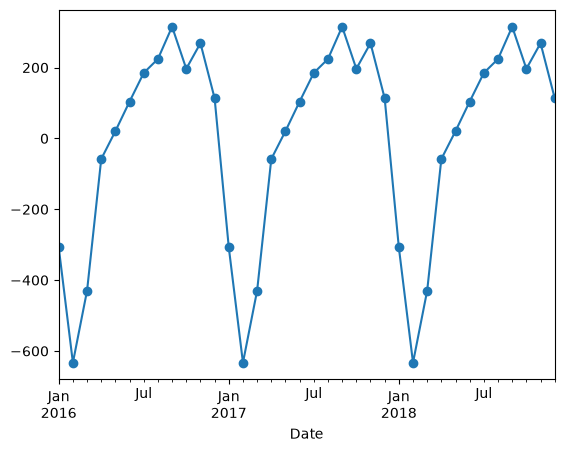

In [74]:
seasonal = decomp.seasonal
ax = seasonal.loc['2016': '2018'].plot(marker = 'o')

The seasonality effect is less that 1% so we will neglect it and go with the nonseasonal forecasting.

Now let's see if differencing is required, and just to be 100% sure that this is not seasonal, we will try to observe the results of the seasonal differencing

In [75]:
# Check for stationarity
get_adfuller_results(ts_oregon_monthly)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-1.786015,3,224,0.387427,0.05,False


Yes, differencing is needed.

In [76]:
# determine d
d = ndiffs(ts_oregon_monthly)
print (f'd = {d}')
# determine D
D = nsdiffs(ts_oregon_monthly, m = 12)
print (f'D = {D}')

d = 2
D = 0


See, what we have here tells us that we won't need seasonality, and to this evidence irrefutable we will plot acf and pacf while considering both seasonality and nonseasonality.

Now let's apply the nonseasonal differences needed.

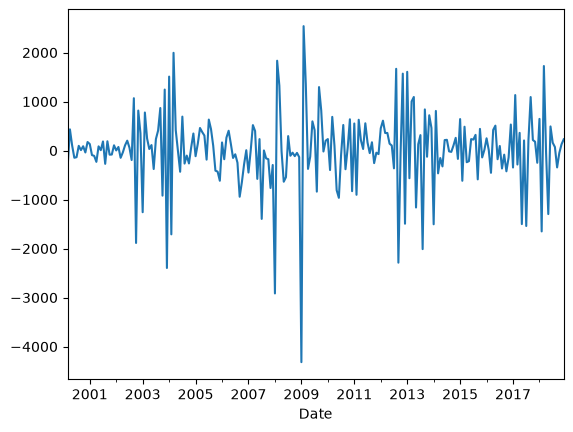

In [77]:
ts_diff = ts_oregon_monthly.diff().diff().dropna()
ts_diff.plot();

In [78]:
get_adfuller_results(ts_diff)

,Test Statistic,# of Lags Used,# of Observations,p-value,alpha,sig/stationary?
adfuller,-13.956007,1,224,0.0,0.05,True


Now let's plot

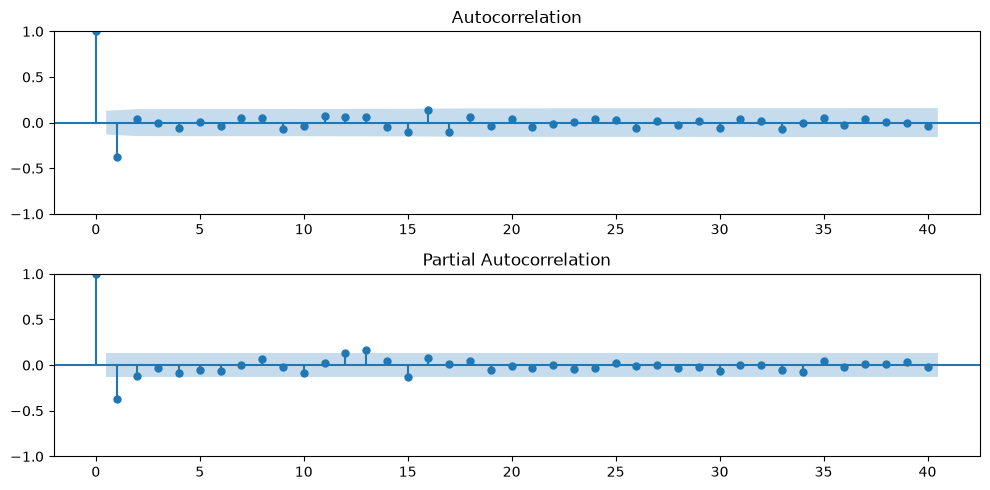

In [79]:
# now look at the acf/pacf of the stationary data
plot_acf_pacf(ts_diff);

Now we can notice a sudden drop after the first element in both acf and pacf.

Now let's plot the seasonal acf and pacf

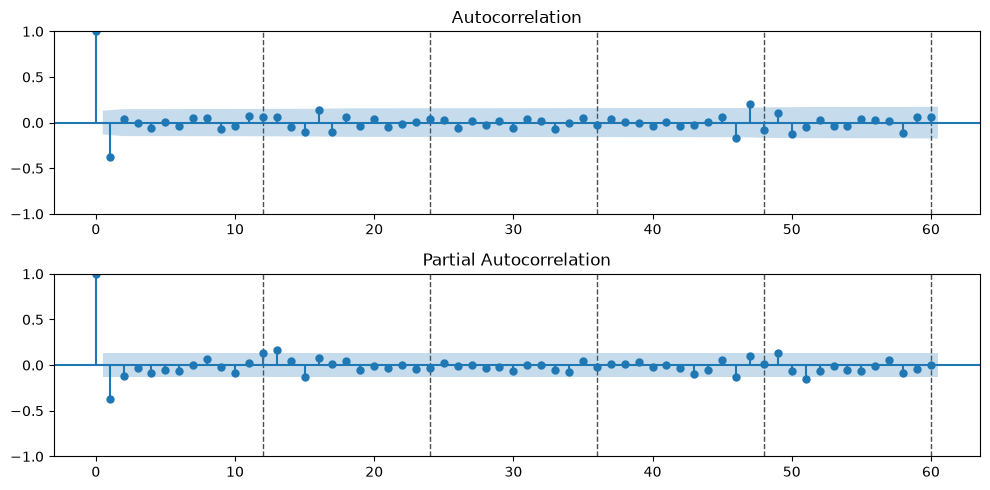

In [80]:
plot_acf_pacf(ts_diff, annotate_seas = True, m = 12, nlags = 60);

Now we are 1000% precent sure that we don't need seasonality.

Now let's make the train and test splits, but since our whole purpose is to predict the incoming 12 months, then we will only make the testing set to be the size of 12 to better simulate the real deployment.

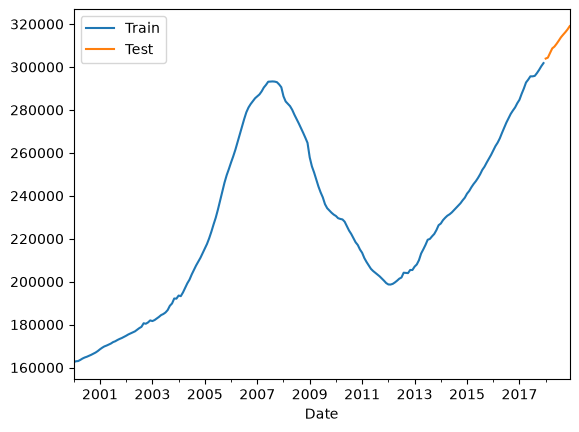

In [81]:
train, test = train_test_split(ts_oregon_monthly, test_size=12)
ax = train.plot(label='Train')
test.plot(ax=ax, label='Test')
ax.legend()

In [82]:
# Orders for non seasonal components
p = 1  # nonseasonal AR
d = 2  # nonseasonal differencing
q = 1  # nonseasonal MA

arima = tsa.ARIMA(train, order = (p,d,q)).fit()

# Obtain summary
arima.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             Home Value   No. Observations:                  216
Model:                 ARIMA(1, 2, 1)   Log Likelihood               -1725.837
Date:                Sat, 18 Jul 2026   AIC                           3457.674
Time:                        11:37:52   BIC                           3467.772
Sample:                    01-31-2000   HQIC                          3461.755
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5758      1.083      0.532      0.595      -1.548       2.699
ma.L1         -0.5967      1.091     -0.547      0.585      -2.735       1.542
sigma2      5.151e+05    2.2e+04     23.396      0.000    4.72e+05    5.58e+05
===================================================================================
Ljung-Box (L1) (Q):                  26.30   Jarque-Bera (JB):               363.31
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.30   Skew:                            -1.16
Prob(H) (two-sided):                  0.28   Kurtosis:                         8.95
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

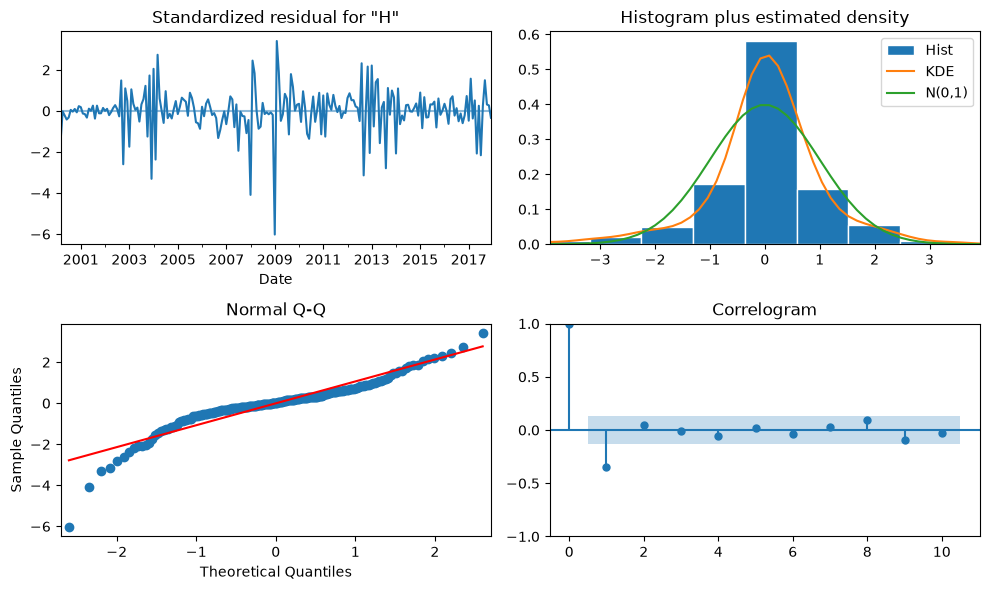

In [83]:
# Obtain diagnostic plots
fig = arima.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

The results aren't the greatest results out there, but considering the fluctuations in the home prices, these results are good.

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 385.086
- MSE = 207,923.649
- RMSE = 455.986
- R^2 = 0.991
- MAPE = 0.12%


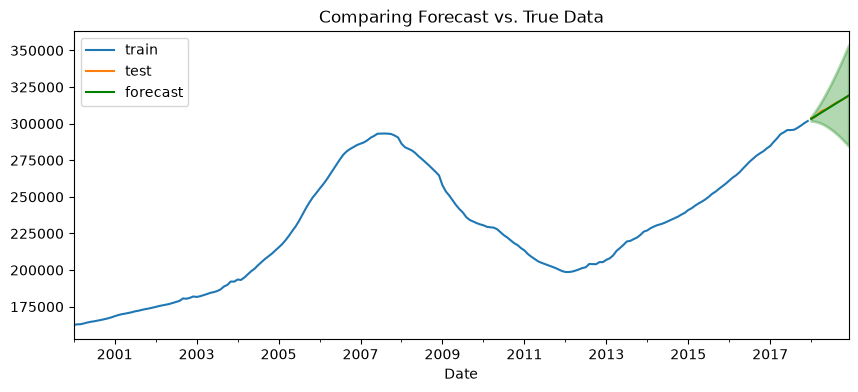

In [84]:
# Obtain forecast as a dataframe with confidence intervals
forecast_df = arima.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

The scores are actually fantastic! considering the forecast fit and the metrics.

Now let's see the autoarima

In [85]:
auto_model = pm.auto_arima(
    train
)

Now the best order generated by the auto_arima

In [86]:
print(auto_model.order)

(1, 1, 1)


In [87]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  216
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1888.586
Date:                Sat, 18 Jul 2026   AIC                           3783.172
Time:                        12:14:04   BIC                           3793.284
Sample:                    01-31-2000   HQIC                          3787.257
                         - 12-31-2017                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9386      0.020     48.067      0.000       0.900       0.977
ma.L1         -0.9074      0.022    -40.482      0.000      -0.951      -0.863
sigma2      2.245e+06   5.06e-10   4.44e+15      0.000    2.24e+06    2.24e+06
===================================================================================
Ljung-Box (L1) (Q):                 160.38   Jarque-Bera (JB):                27.58
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.59   Skew:                            -0.72
Prob(H) (two-sided):                  0.03   Kurtosis:                         4.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.51e+31. Standard errors may be unstable.
"""

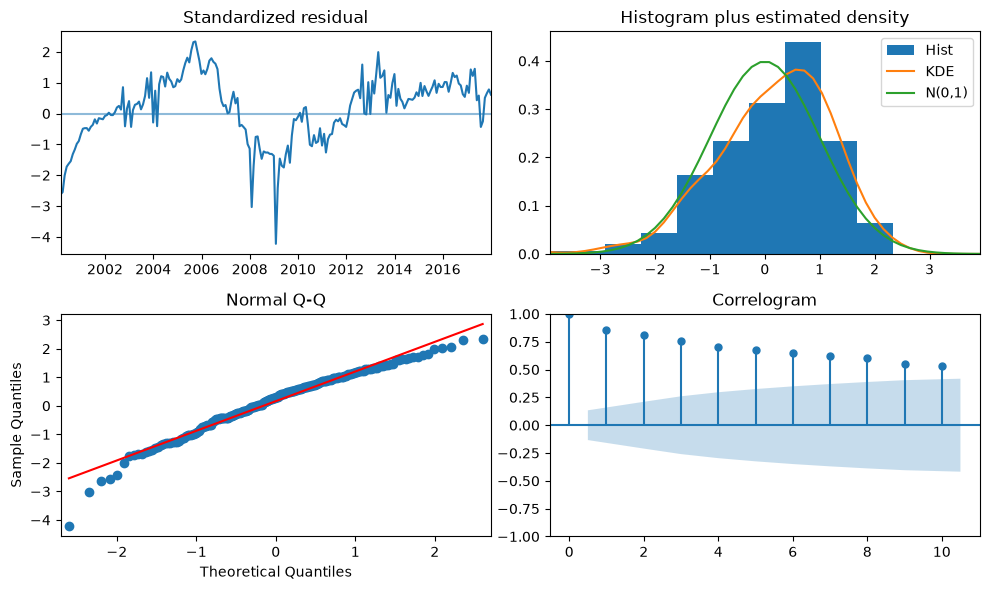

In [88]:
fig = auto_model.plot_diagnostics()
fig.set_size_inches(10,6)
fig.tight_layout()

These graphs are worse that what we got with the manual arima.

------------------------------------------------------------
Regression Metrics: 
------------------------------------------------------------
- MAE = 6,888.614
- MSE = 60,135,168.295
- RMSE = 7,754.687
- R^2 = -1.583
- MAPE = 2.19%


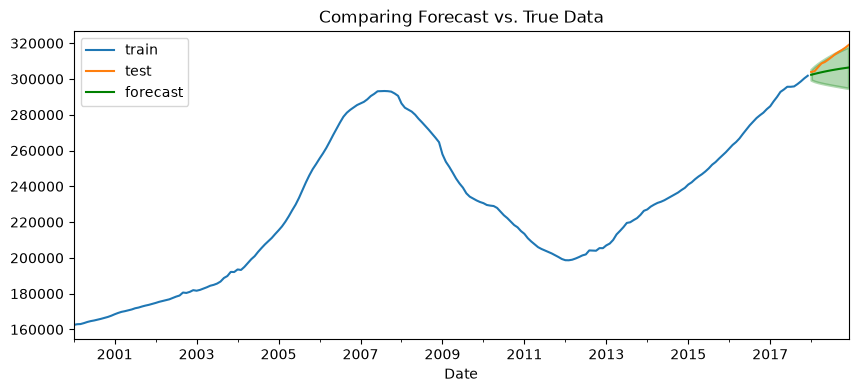

In [89]:
# Use auto_arima parameters to fit an ARIMA
auto_model = tsa.ARIMA(
    train, order=auto_model.order
).fit()


# Obtain forecast as a dataframe with confidence intervals
forecast_df = auto_model.get_forecast(steps=len(test)).summary_frame()
# Call the custom function to plot the forecasts with confidence intervals and true values
plot_forecast(train, test, forecast_df);
# Obtain metrics
regression_metrics_ts(test, forecast_df['mean'])

These results are really bad

Now we will continue on with the regular arima model.
looking at the results of AIC, BIC, R^2, MAPE, and even the plots, we observe that the regular arima model we created was much better.

Now let's make future predictions

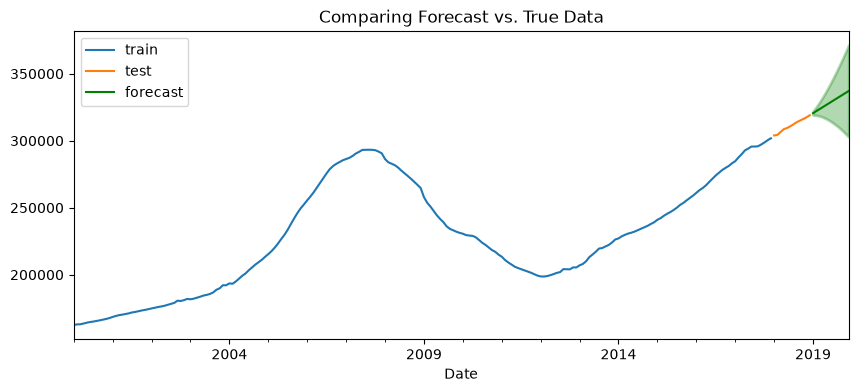

In [90]:
final_model = tsa.ARIMA(
    ts_oregon_monthly, order=(1, 2, 1)
).fit()
forecast_df  = final_model.get_forecast(12).summary_frame()
plot_forecast(train,test,forecast_df);

Period of forecasting

In [91]:
forecast_df.index[0],forecast_df.index[-1]

(Timestamp('2019-01-31 00:00:00'), Timestamp('2019-12-31 00:00:00'))

Starting value of the forecast

In [92]:
starting_value = forecast_df['mean'].iloc[0]
print(f'The starting value of the forecasts is {starting_value}')

The starting value of the forecasts is 320538.1615729808


Ending value of the forecast

In [93]:
final_value = forecast_df['mean'].iloc[-1]
print(f'The starting value of the forecasts is {final_value}')

The starting value of the forecasts is 337119.7462517531


amount of change

In [94]:
change = final_value - starting_value
change

np.float64(16581.584678772313)

Percentage of change

In [95]:
perc_change = (change / starting_value) * 100
perc_change

np.float64(5.1730454175569305)

# Tableau Workbook <br/>
https://public.tableau.com/shared/PCZKSQ7WP?:display_count=n&:origin=viz_share_link